# 3.1 — The linear model

> *"All models are wrong; some are useful."* — George Box.
> For a book of futures, the linear model is the rare one that is also nearly *right*.

## The problem

Someone told you that hedging uses "a linear model" or "a linear numerical method". They were pointing
at the same thing: the idea that the change in value of a portfolio is, to first order, a **weighted sum
of the changes in a handful of market prices**, with weights called *deltas* (or *sensitivities*). Every
number in Module 2 — hedge ratios, residual variance, the pipeline's risk report — was an application of
it. This chapter makes it explicit, shows *why* it is exact for futures and where it stops being exact,
and derives the two formulas that everything else in Module 3 rests on:

$$
\Delta V \approx \boldsymbol{\Delta}^{\top}\Delta\mathbf{P}
\qquad\text{and}\qquad
\text{Var}(\Delta V) = \boldsymbol{\Delta}^{\top}\Sigma\,\boldsymbol{\Delta}
$$

In [1]:
import sys, pathlib
_root = pathlib.Path.cwd().resolve()
while not (_root / "gashedge").exists():
    _root = _root.parent
sys.path.insert(0, str(_root))

from datetime import date
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from gashedge import get_logger
from gashedge.plotting import setup_style

from gashedge.market_data import simulate_curve_history, month_bucket
from gashedge.risk import linear_pnl, portfolio_variance, risk_contributions
from gashedge.plotting import plot_heatmap
setup_style()
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 30)
log = get_logger("ch3.1")
log.info("Environment ready")

2026-09-13 16:47:10.230 | INFO    | ch3.1 | Environment ready


## 1. From Taylor to delta

Let the book's value depend on $n$ market prices, $V(P_1, \dots, P_n)$. Expand around today's prices:

$$
\Delta V \;=\; \sum_i \frac{\partial V}{\partial P_i}\Delta P_i
\;+\; \frac{1}{2}\sum_{i,j} \frac{\partial^2 V}{\partial P_i \partial P_j}\Delta P_i \Delta P_j
\;+\; \dots
\tag{3.1}
$$

The first-order coefficients $\Delta_i = \partial V/\partial P_i$ are the **deltas**; the second-order
matrix is the **gamma**. The *linear model* keeps only the first term.

**For a portfolio of futures and forwards this is not an approximation.** The value of $q$ MWh of a
futures contract is $q\,(P - K)$ for a fixed entry price $K$, so $\partial V/\partial P = q$ and every
second derivative is **zero**. Delta is just the MWh position, gamma is identically zero, and equation
(3.1) is exact:

$$
\Delta V = \sum_i q_i\,\Delta P_i = \mathbf{q}^{\top}\Delta\mathbf{P}
\tag{3.2}
$$

This is why a gas *futures* book can be risk-managed with such simple machinery, and why the linear
model is the industry standard for it. Where does it break?

* **Options** — gamma is not zero; you need (3.1) to second order at least. Out of scope here.
* **Currency conversions** — NBP is quoted in pence/therm; a EUR book's value is
  $q \cdot P_{\text{GBp/th}} \cdot \text{FX}_{\text{EURGBP}} \cdot \text{conv}$, a *product* of two
  risk factors, so there is a cross-gamma term $\partial^2 V/\partial P\,\partial\text{FX}$. Small for a
  day, not negligible in a 2022-sized move.
* **Strips vs months** — none; a strip *is* a linear combination of months (Chapter 1.2).
* **Physical assets** (storage, swing, transport) — deeply nonlinear; that is a different course.

## 2. The delta ladder

Write the book as a vector of MWh per instrument. For a curve book the instruments are the tenors
M1..M24 (constant-maturity buckets), possibly per hub. This vector *is* the risk report.

2026-09-13 16:47:10.238 | INFO    | gashedge.market_data | Simulated constant-maturity curve history: 750 days x 24 tenors


2026-09-13 16:47:10.273 | INFO    | ch3.1 | Book: net 18000 MWh, gross 102000 MWh


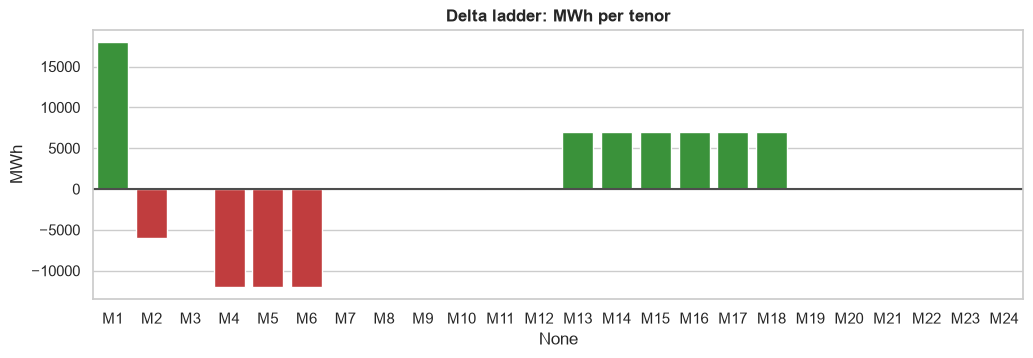

In [2]:
hist = simulate_curve_history(n_days=750, n_tenors=24)
dP = hist.diff().dropna()                   # EUR/MWh daily changes: the Delta P vector, one row per day
tenors = list(hist.columns)

# A stylised book: long the front, short the middle, long a far winter strip - the residue of MM activity
book = pd.Series(0.0, index=tenors, name="delta_mwh")
book[["M1", "M2"]] = [18_000, -6_000]
book[["M4", "M5", "M6"]] = -12_000
book[["M13", "M14", "M15", "M16", "M17", "M18"]] = 7_000
fig, ax = plt.subplots(figsize=(12, 3.5))
sns.barplot(x=book.index, y=book.values, hue=np.sign(book.values), palette={1: "tab:green", -1: "tab:red", 0: "0.7"}, legend=False, ax=ax)
ax.axhline(0, color="0.3"); ax.set_title("Delta ladder: MWh per tenor"); ax.set_ylabel("MWh")
log.info("Book: net %.0f MWh, gross %.0f MWh", book.sum(), book.abs().sum())

Net exposure is small; gross is large. Which number is the risk? Neither, as the next equation shows.

## 3. The variance of a linear portfolio

Take the variance of (3.2). With $\Sigma = \text{Cov}(\Delta\mathbf{P})$, the $n\times n$ covariance
matrix of daily price changes,

$$
\text{Var}(\Delta V) = \text{Var}(\mathbf{q}^{\top}\Delta\mathbf{P}) = \mathbf{q}^{\top}\,\Sigma\,\mathbf{q}
= \sum_i\sum_j q_i q_j \Sigma_{ij}
\tag{3.3}
$$

This is the single most used formula in market risk. Read it as: *the risk of a book is the sum over
every pair of positions of their product times their covariance.* Two positions with the same sign in
highly correlated tenors add risk; opposite signs subtract it. Net MWh ignores the covariances; gross MWh
ignores the signs. Only (3.3) gets it right.

In [3]:
Sigma = dP.cov()
var_book = portfolio_variance(book, Sigma)
realised = pd.Series(linear_pnl(book, dP), index=dP.index, name="daily_pnl")
log.info("Model daily std %.0f EUR vs realised std of Delta'dP series %.0f EUR (identical by construction)",
         np.sqrt(var_book), realised.std())
naive_net = abs(book.sum()) * dP.M1.std()
naive_gross = book.abs().sum() * dP.M1.std()
pd.Series({"model std (Delta' Sigma Delta)^0.5": np.sqrt(var_book), "'net MWh x front vol'": naive_net,
           "'gross MWh x front vol'": naive_gross}, name="EUR/day").round(0)

2026-09-13 16:47:10.360 | INFO    | ch3.1 | Model daily std 14883 EUR vs realised std of Delta'dP series 14883 EUR (identical by construction)


model std (Delta' Sigma Delta)^0.5     14883.0
'net MWh x front vol'                  23457.0
'gross MWh x front vol'               132925.0
Name: EUR/day, dtype: float64

## 4. Where the risk comes from: Euler contributions

Because $\sigma_V = \sqrt{\mathbf{q}^\top\Sigma\mathbf{q}}$ is homogeneous of degree one in $\mathbf{q}$,
Euler's theorem gives an exact decomposition of total volatility into per-position contributions:

$$
\sigma_V = \sum_i q_i \frac{\partial \sigma_V}{\partial q_i} = \sum_i \frac{q_i\,(\Sigma\mathbf{q})_i}{\sigma_V}
\tag{3.4}
$$

Each term is the *marginal* contribution of position $i$: how much $\sigma_V$ would fall if you removed a
small slice of it. Negative contributions are positions that **hedge** the rest of the book. This is the
report that tells the hedger *which* tenor to trade first.

2026-09-13 16:47:10.390 | INFO    | ch3.1 | Contributions sum to 14883 = total std 14883. Largest: M1 (11344)


M1     11344.0
M2     -1970.0
M4     -4376.0
M5     -4651.0
M6     -3882.0
M13     3264.0
M14     2821.0
M15     3188.0
M16     3001.0
M17     3059.0
M18     3085.0
Name: vol_contribution, dtype: float64

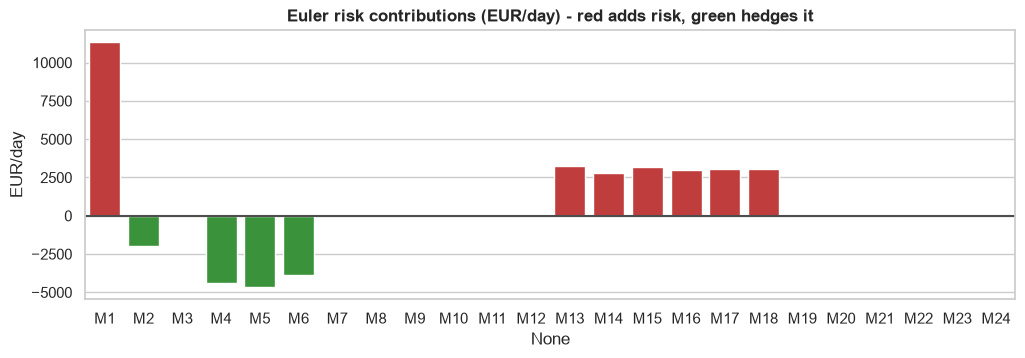

In [4]:
contrib = risk_contributions(book, Sigma)
fig, ax = plt.subplots(figsize=(12, 3.5))
sns.barplot(x=contrib.index, y=contrib.values, hue=np.sign(contrib.values), palette={1: "tab:red", -1: "tab:green", 0: "0.7"}, legend=False, ax=ax)
ax.axhline(0, color="0.3"); ax.set_title("Euler risk contributions (EUR/day) - red adds risk, green hedges it"); ax.set_ylabel("EUR/day")
log.info("Contributions sum to %.0f = total std %.0f. Largest: %s (%.0f)", contrib.sum(), np.sqrt(var_book), contrib.abs().idxmax(), contrib[contrib.abs().idxmax()])
contrib[contrib != 0].round(0)

The far-winter strip contributes little despite being the largest gross position, because back-month
volatility is low (Samuelson, Chapter 1.4). The M4–M6 shorts *reduce* risk — they hedge the M1 long
through correlation. The first hedge to trade is against the biggest red bar.

## 5. The best hedge is a linear-algebra statement

Now add a hedge. Let $\mathbf{w}$ be the MWh vector we trade in a set of $k$ hedge instruments with
covariance $\Sigma_{FF}$ and cross-covariance with the book's P&L $\Sigma_{FV} = \text{Cov}(\Delta \mathbf{F}, \Delta V)$.
Hedged variance:

$$
\text{Var}(\Delta V + \mathbf{w}^\top\Delta\mathbf{F}) = \sigma_V^2 + 2\,\mathbf{w}^\top\Sigma_{FV} + \mathbf{w}^\top\Sigma_{FF}\mathbf{w}
\tag{3.5}
$$

Differentiate with respect to $\mathbf{w}$ and set to zero:

$$
\mathbf{w}^{*} = -\,\Sigma_{FF}^{-1}\,\Sigma_{FV}
\tag{3.6}
$$

With a single hedge instrument this collapses to $w^* = -\text{Cov}(\Delta F, \Delta V)/\text{Var}(\Delta F)$ — the
minimum-variance hedge ratio of Chapters 1.4 and 2.1, now for a whole book rather than a single exposure.
Chapter 3.2 studies the one-instrument case in depth (estimation, error bars); Chapter 3.3 the
many-instrument case (3.6) and its numerical pitfalls.

In [5]:
hedge_instruments = ["M1", "M3"]
S_FF = Sigma.loc[hedge_instruments, hedge_instruments].values
S_FV = np.array([np.cov(dP[h], realised, ddof=1)[0, 1] for h in hedge_instruments])
w_star = -np.linalg.solve(S_FF, S_FV)
hedged = book.copy()
for h, w in zip(hedge_instruments, w_star):
    hedged[h] += w
log.info("Optimal hedge in %s: %s MWh -> std falls from %.0f to %.0f EUR/day", hedge_instruments, np.round(w_star).tolist(),
         np.sqrt(var_book), np.sqrt(portfolio_variance(hedged, Sigma)))
pd.DataFrame({"hedge_mwh": pd.Series(w_star, index=hedge_instruments)}).round(0)

2026-09-13 16:47:10.476 | INFO    | ch3.1 | Optimal hedge in ['M1', 'M3']: [-7371.0, 2815.0] MWh -> std falls from 14883 to 12980 EUR/day


,hedge_mwh
M1,-7371.0
M3,2815.0


## 6. Bucketing: how many deltas do you need?

Twenty-four tenors is manageable; 24 tenors × 5 hubs × 3 products is not. Practitioners **bucket**
exposures (M1, M2, M3, M4–M6, M7–M12, M13+) and estimate a smaller $\Sigma$. Bucketing loses the
*within-bucket* spread risk (long M4 / short M6 nets to zero). Whether that matters is an empirical
question — let us measure it on the book above.

2026-09-13 16:47:10.483 | INFO    | ch3.1 | Full model std 14883 EUR/day; bucketed model std 15104 EUR/day


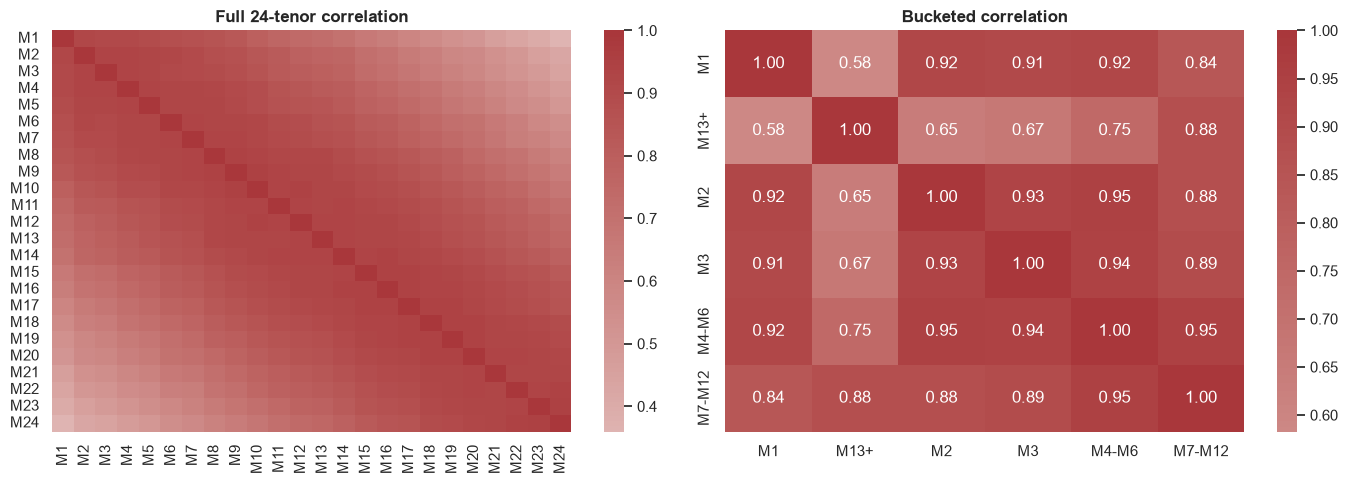

In [6]:
buckets = pd.Series([month_bucket(i) for i in range(1, 25)], index=tenors)
dP_b = dP.T.groupby(buckets).mean().T                      # bucket price change = average of members
book_b = book.groupby(buckets).sum()
Sigma_b = dP_b.cov().loc[book_b.index, book_b.index]
log.info("Full model std %.0f EUR/day; bucketed model std %.0f EUR/day", np.sqrt(var_book), np.sqrt(portfolio_variance(book_b, Sigma_b)))
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_heatmap(dP.corr(), title="Full 24-tenor correlation", ax=axes[0], fmt=".1f")
plot_heatmap(dP_b.corr().loc[book_b.index, book_b.index], title="Bucketed correlation", ax=axes[1])
plt.tight_layout()

## 7. Where this leaves us

For a futures book the linear model is exact: risk is $\mathbf{q}^\top\Sigma\mathbf{q}$, the best hedge
is $-\Sigma_{FF}^{-1}\Sigma_{FV}$, and Euler contributions tell you where to start. Everything depends on
**one object, $\Sigma$**, which we have so far treated as *known*.

**Pitfall that leads to the next chapter:** $\Sigma$ is not known; it is *estimated* from a finite,
non-stationary history, and the hedge ratio inherits every flaw of that estimate. Chapter 3.2 takes the
simplest case — one exposure, one hedge — and asks how wrong $h$ can be, using the least-squares theory
of [Appendix A](../appendix/A_least_squares.ipynb).

### Check your understanding

Work these on paper (or in a scratch cell) *before* expanding the answers.

**Q1.** A book is long 10,000 MWh of M1 and short 10,000 MWh of M2. Daily vols are 1.20 and 1.10 EUR/MWh, correlation 0.94. Compute the daily P&L standard deviation with (3.3). Then compute what 'net MWh × front vol' and 'gross MWh × front vol' would have said.

<details><summary><i>Answer 1</i></summary>

$\text{Var} = q_1^2\sigma_1^2 + q_2^2\sigma_2^2 + 2q_1q_2\rho\sigma_1\sigma_2 = 10^8(1.44 + 1.21 - 2\times0.94\times1.32) = 10^8(2.65 - 2.4816) = 10^8 \times 0.1684$; $\sigma_V = 10^4\times\sqrt{0.1684} = \mathbf{€4{,}104/day}$. Net MWh $= 0$ → 'net × vol' says **0** (wrong: the spread has risk). Gross $= 20{,}000$ → 'gross × vol' says **€24,000** (wrong by 6×: it ignores that the legs offset). Only the covariance formula is right.

</details>

**Q2.** Explain why gamma is exactly zero for a futures position but *not* for an NBP futures position held in a EUR-denominated book. Write the second-order term.

<details><summary><i>Answer 2</i></summary>

Futures value $= q(P-K)$ is linear in $P$, so all second derivatives vanish. An NBP position in EUR is $V = q\cdot P_{\text{GBp/th}} \cdot c \cdot X$ where $c$ converts therms to MWh and $X$ is the EUR per GBp rate; this is a *product* of two risk factors. $\partial^2 V/\partial P\,\partial X = q\,c \neq 0$, so the second-order term is $q\,c\,\Delta P\,\Delta X$ — a *cross-gamma*. It is small for daily moves (product of two small numbers) but in a 2022-type week with $\Delta P/P \sim 50\%$ and $\Delta X/X \sim 3\%$ it is ~1.5 % of position value — not something a 'linear' risk report should silently omit.

</details>

**Q3.** Using Euler's theorem (3.4), a position's risk contribution can be negative. Give an intuitive explanation, and state what happens to total risk if you *increase* such a position slightly.

<details><summary><i>Answer 3</i></summary>

The contribution $q_i(\Sigma\mathbf{q})_i/\sigma_V$ is $q_i$ times the covariance of instrument $i$'s price change with the whole book's P&L, divided by $\sigma_V$. It is negative when the position moves *against* the rest of the book — i.e. it is a hedge for the remainder. Increasing such a position slightly **reduces** total volatility (the derivative $\partial\sigma_V/\partial q_i$ has the sign of the contribution) — until it grows so large that it becomes the dominant risk itself, at which point its contribution turns positive.

</details>

**Q4.** Bucketing M4, M5, M6 into one bucket made the model risk of the book change. In what circumstances would bucketing *understate* risk badly, and how would you detect it from the delta ladder alone?

<details><summary><i>Answer 4</i></summary>

Bucketing sums positions within the bucket, so **offsetting positions inside a bucket disappear** (long M4 / short M6 → zero bucket delta) even though the M4–M6 spread has real, if small, volatility. It understates badly when the book runs large *intra-bucket spreads* — typical of desks trading calendar spreads, or of stacked hedges awaiting migration (Chapter 2.6) where the stack sits in M3 and the exposure in M5. Detect it by comparing **gross** MWh within each bucket to the **net** bucket delta: a ratio far above 1 flags hidden spread risk that needs either finer buckets or an explicit spread-risk add-on.

</details>


---
◀ [Previous](../module2_hedging_core/06_proxy_hedging_pipeline.ipynb) · [Contents](../00_introduction.ipynb) · [Next ▶](02_minimum_variance_hedge.ipynb)